In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

sns.set(style="whitegrid")


In [3]:
with open("data/subcategory_aggregates.json", "r",  encoding="utf-8") as f:
    aggregates = json.load(f)

with open("data/subcategory_messages.json", "r",  encoding="utf-8") as f:
    sub_messages = json.load(f)

with open("data/subcategory_registry.json", "r",  encoding="utf-8") as f:
    registry = json.load(f)

print("Loaded successfully")


Loaded successfully


In [4]:
rows = []

for category, subcats in aggregates.items():
    for subcat, meta in subcats.items():
        rows.append({
            "category": category,
            "subcategory": subcat,
            "message_count": meta["message_count"],
            "unique_users": len(meta["unique_user_ids"])
        })

df = pd.DataFrame(rows)

df.head()


,category,subcategory,message_count,unique_users
0,Churn Signals,Direct Cancellation,941,286
1,Churn Signals,Dissatisfaction,63,26
2,Churn Signals,Scheduling Issues,52,24
3,Churn Signals,Child Disinterest,45,17
4,Churn Signals,Temporary Pause,83,31


In [5]:
print("Total Categories:", df["category"].nunique())
print("Total Subcategories:", df["subcategory"].nunique())
print("Total Messages:", df["message_count"].sum())
print("Total Unique Users:", df["unique_users"].sum())


Total Categories: 15
Total Subcategories: 142
Total Messages: 17154
Total Unique Users: 9950


In [6]:
df["category_total"] = df.groupby("category")["message_count"].transform("sum")
df["percentage_inside_category"] = (
    df["message_count"] / df["category_total"] * 100
)

df.sort_values(["category", "message_count"], ascending=[True, False])


,category,subcategory,message_count,unique_users,category_total,percentage_inside_category
130,Account Management,Contact Info,39,32,208,18.750000
131,Account Management,Communication Preferences,33,22,208,15.865385
132,Account Management,Account Access,32,21,208,15.384615
135,Account Management,Enrollment,21,17,208,10.096154
129,Account Management,Personal Info,16,14,208,7.692308
...,...,...,...,...,...,...
72,Trial Class,Trial Issues,48,37,724,6.629834
75,Trial Class,Trial Confirmation,39,29,724,5.386740
73,Trial Class,Trial Reschedule,37,33,724,5.110497
76,Trial Class,Trial Completion,22,20,724,3.038674


In [7]:
df.sort_values("message_count", ascending=False).head(15)


,category,subcategory,message_count,unique_users,category_total,percentage_inside_category
12,Other,Acknowledgment,1951,837,3793,51.436857
30,Class Management,Rescheduling,1109,514,6747,16.436935
0,Churn Signals,Direct Cancellation,941,286,1341,70.171514
16,Other,Other,876,478,3793,23.095175
33,Class Management,Class Confirmation,851,455,6747,12.613013
36,Class Management,Availability Inquiry,808,372,6747,11.975693
34,Class Management,Timing Inquiry,695,344,6747,10.300874
37,Class Management,Other,683,353,6747,10.123018
18,Other,Confirmation,633,502,3793,16.688637
40,Class Management,Scheduling,576,283,6747,8.537128


In [8]:
df["avg_messages_per_user"] = (
    df["message_count"] / df["unique_users"]
)

df.sort_values("avg_messages_per_user", ascending=False).head(10)


,category,subcategory,message_count,unique_users,category_total,percentage_inside_category,avg_messages_per_user
5,Churn Signals,Financial Reasons,42,12,1341,3.131991,3.500000
0,Churn Signals,Direct Cancellation,941,286,1341,70.171514,3.290210
4,Churn Signals,Temporary Pause,83,31,1341,6.189411,2.677419
3,Churn Signals,Child Disinterest,45,17,1341,3.355705,2.647059
7,Churn Signals,Teacher Resignation,5,2,1341,0.372856,2.500000
1,Churn Signals,Dissatisfaction,63,26,1341,4.697987,2.423077
6,Churn Signals,Other Reasons,68,29,1341,5.070843,2.344828
12,Other,Acknowledgment,1951,837,3793,51.436857,2.330944
70,Trial Class,Scheduling,53,23,724,7.320442,2.304348
24,General Questions,Acknowledgements,399,175,1123,35.529831,2.280000


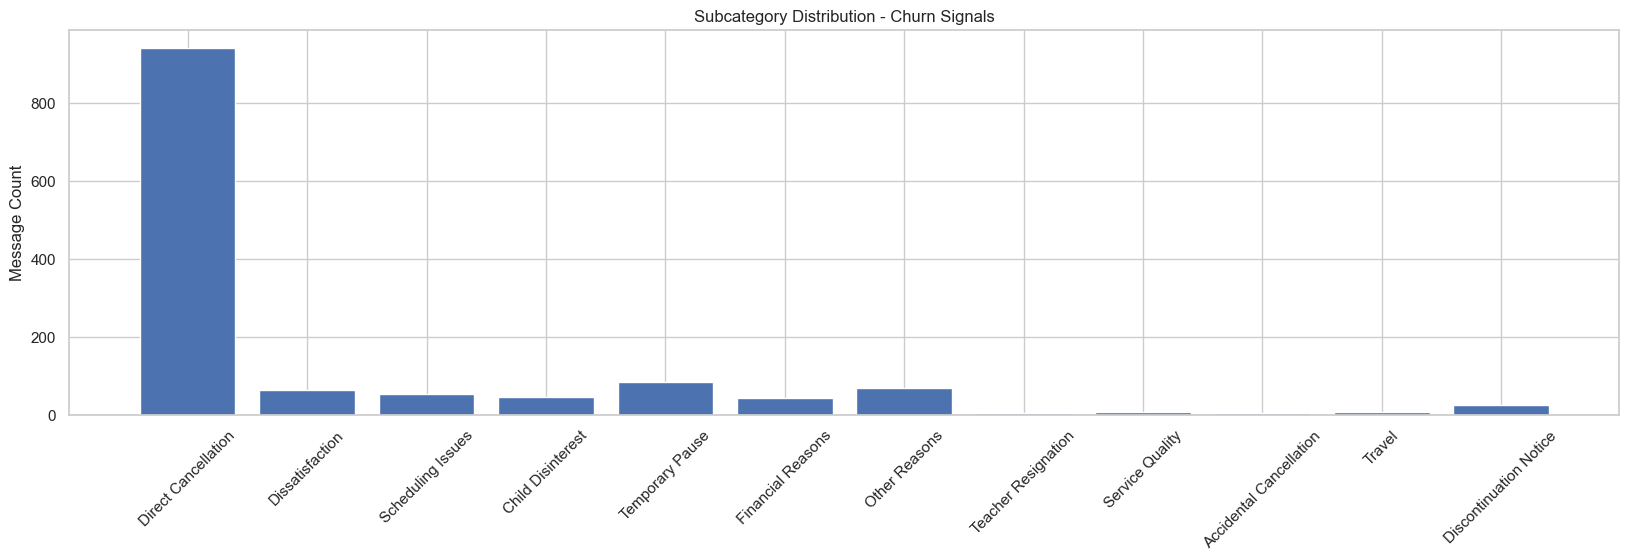

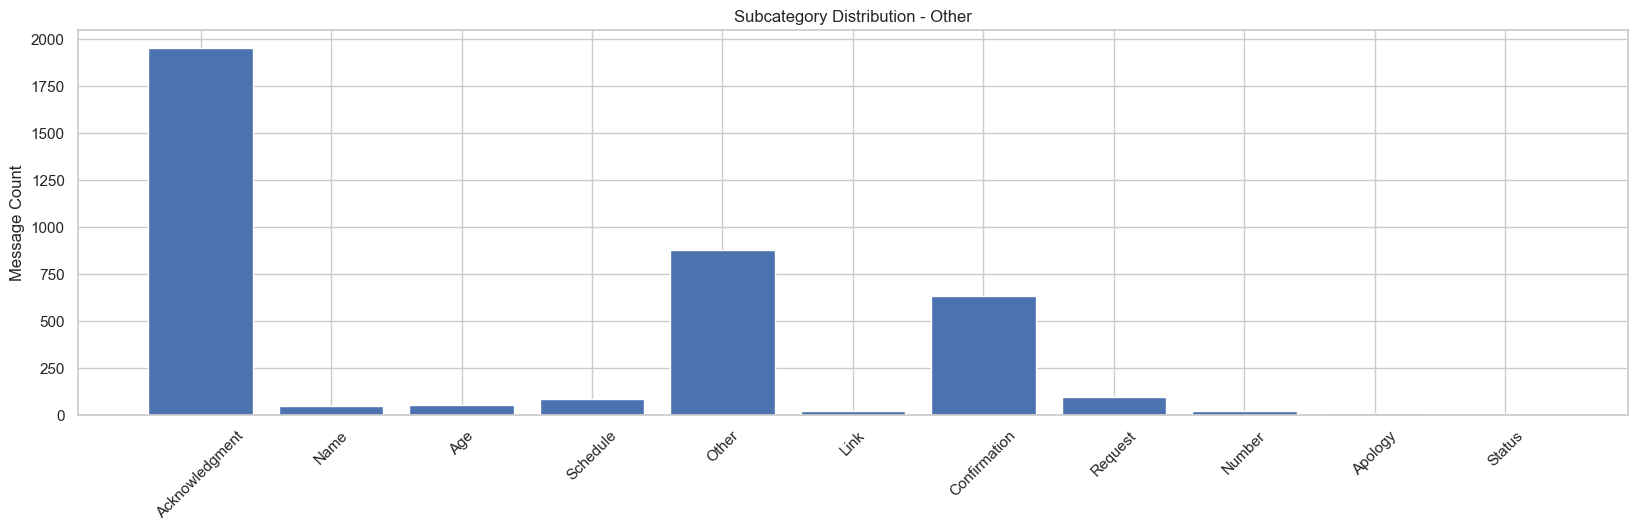

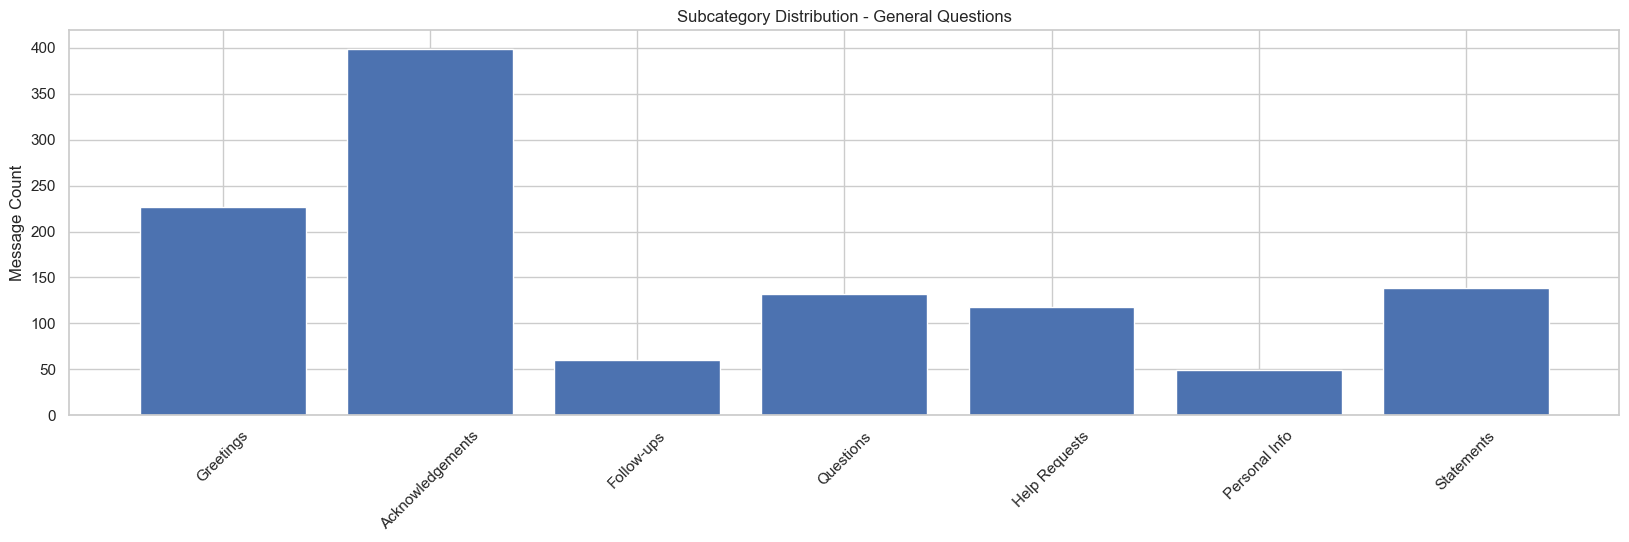

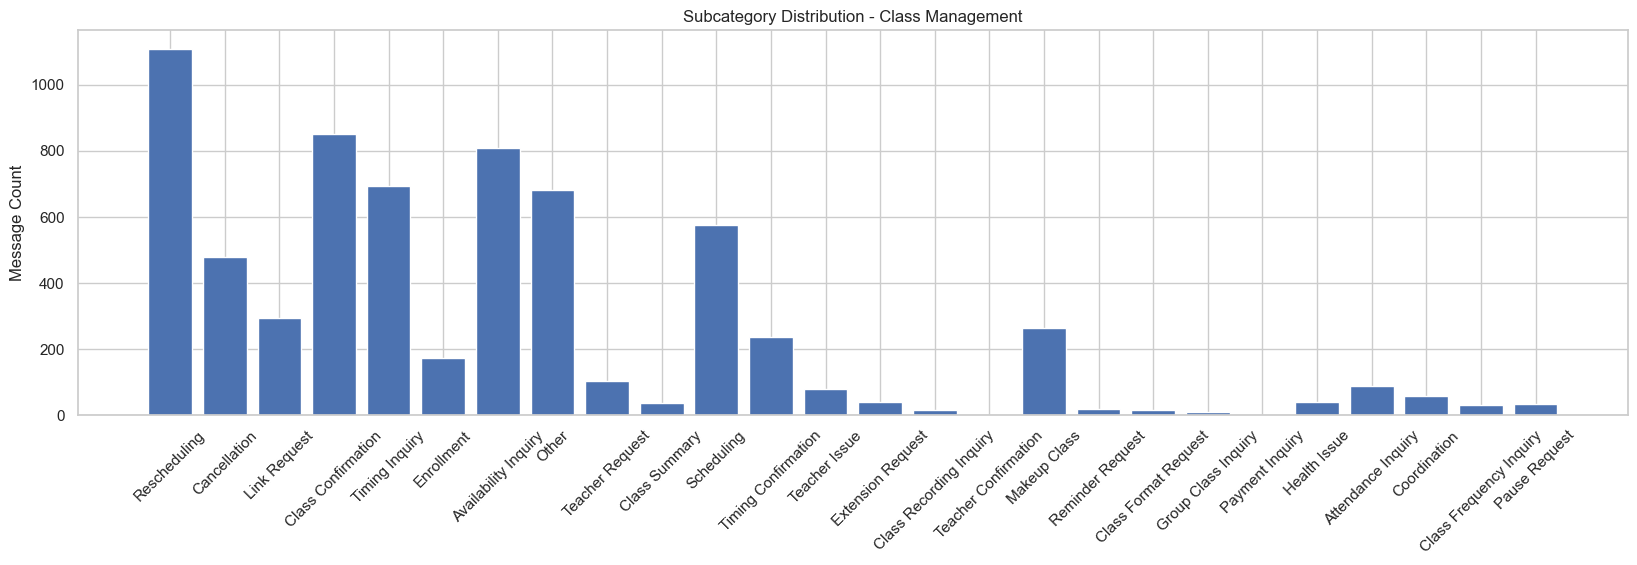

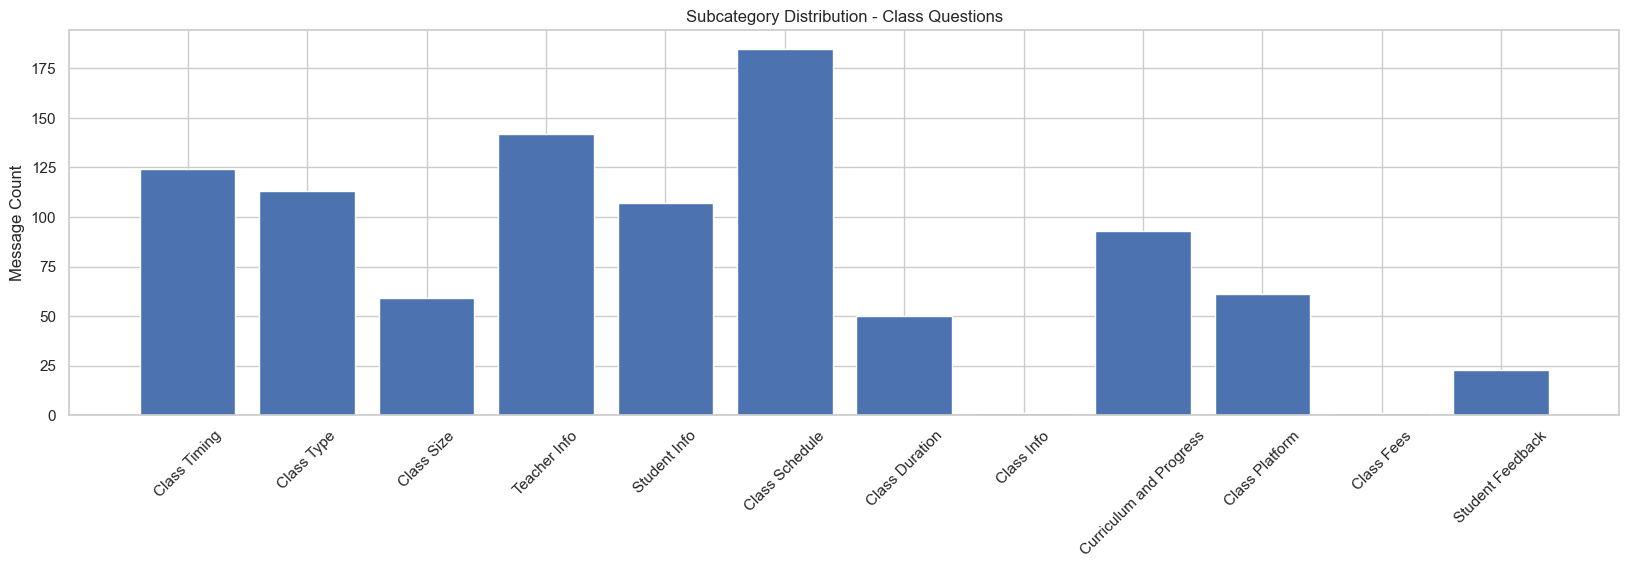

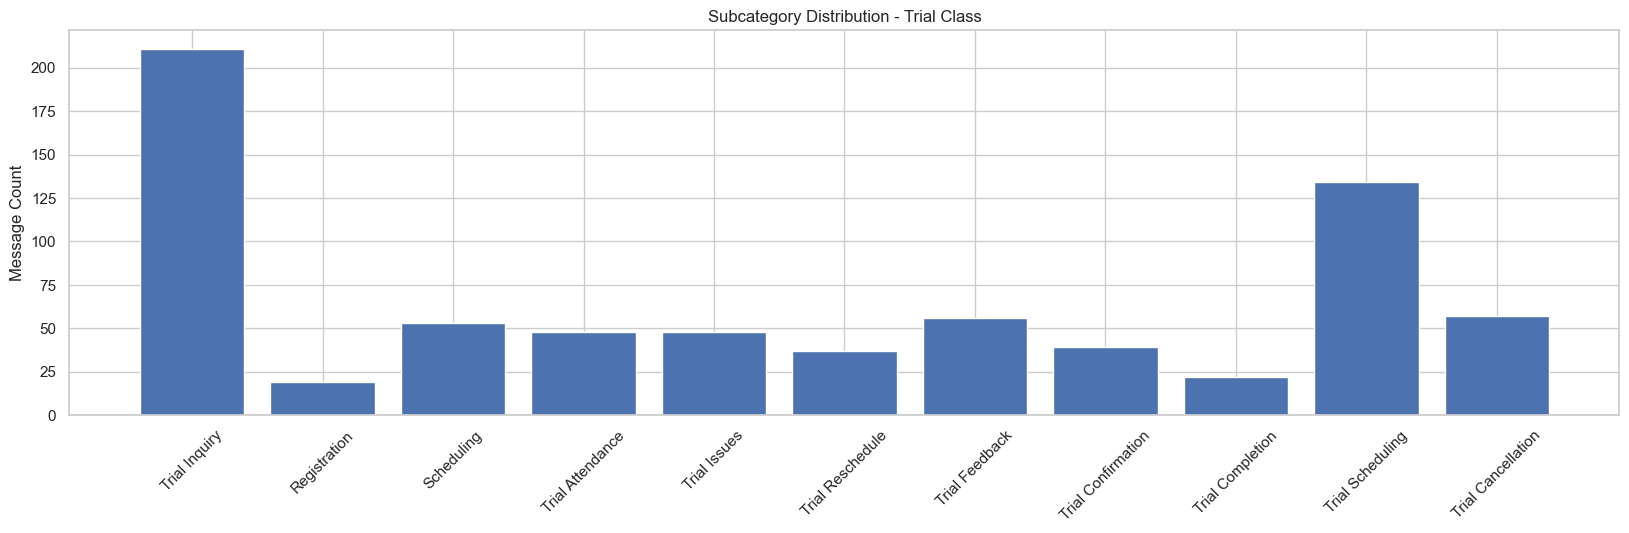

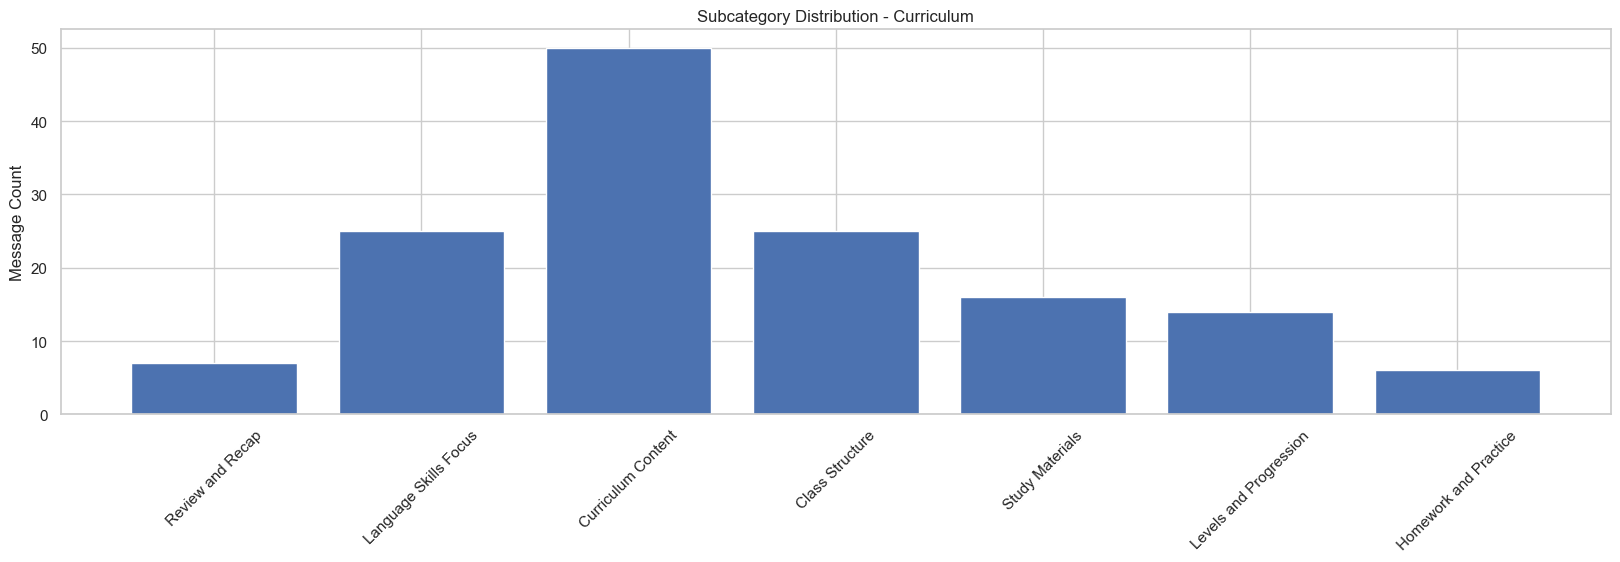

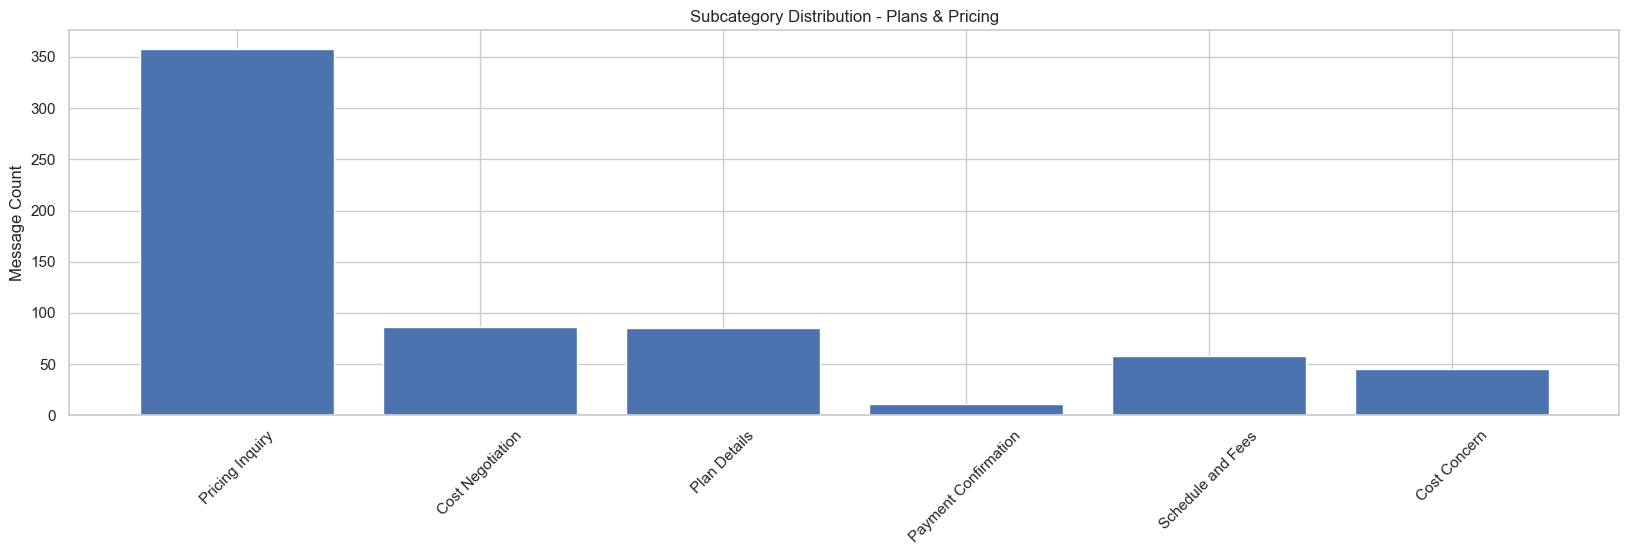

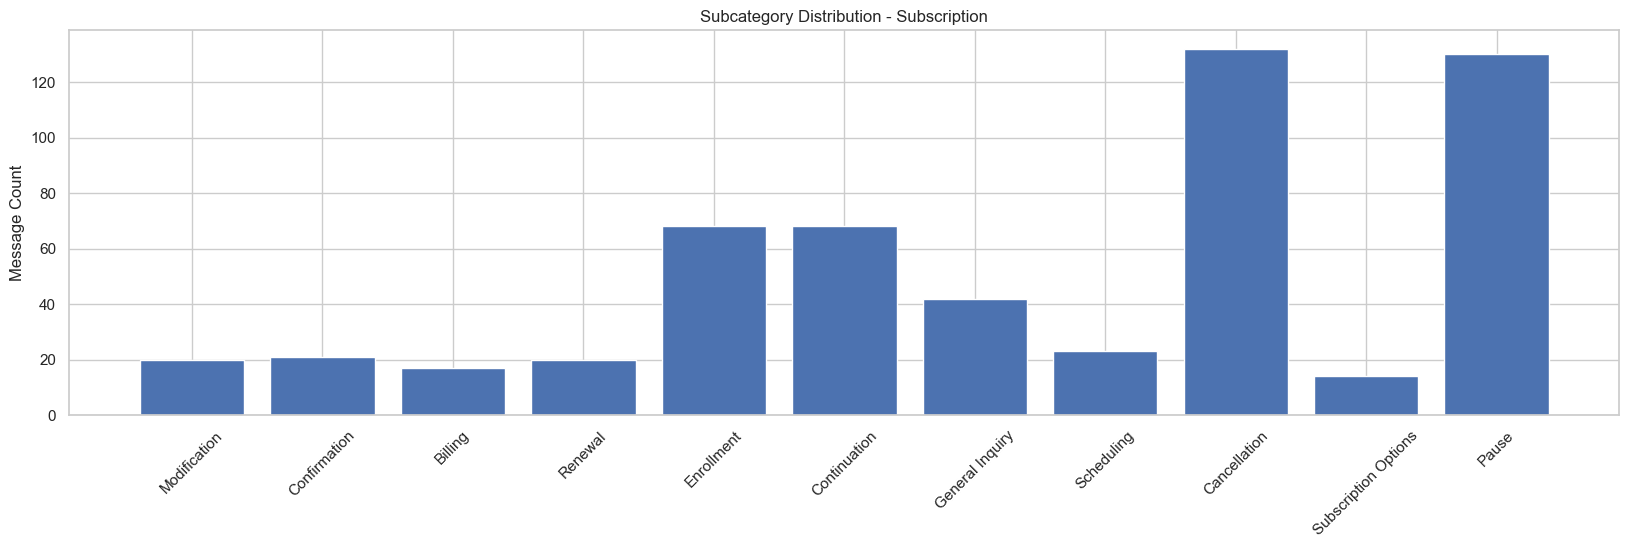

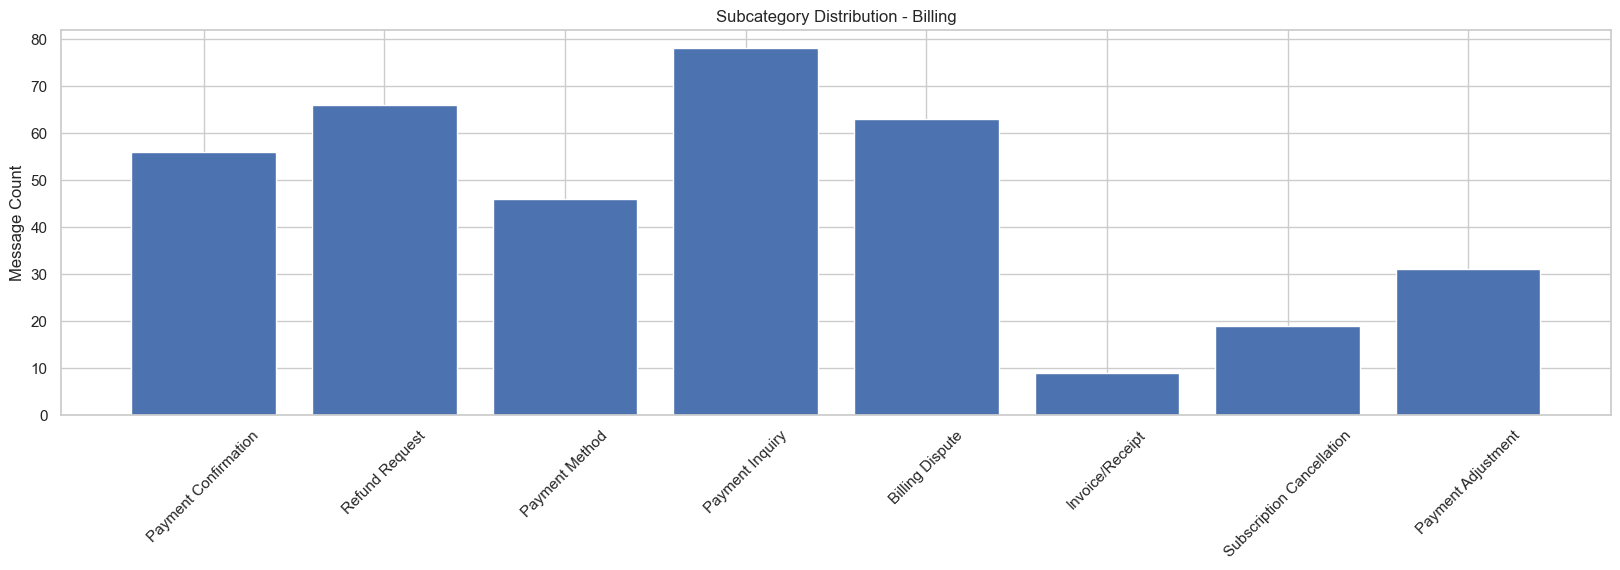

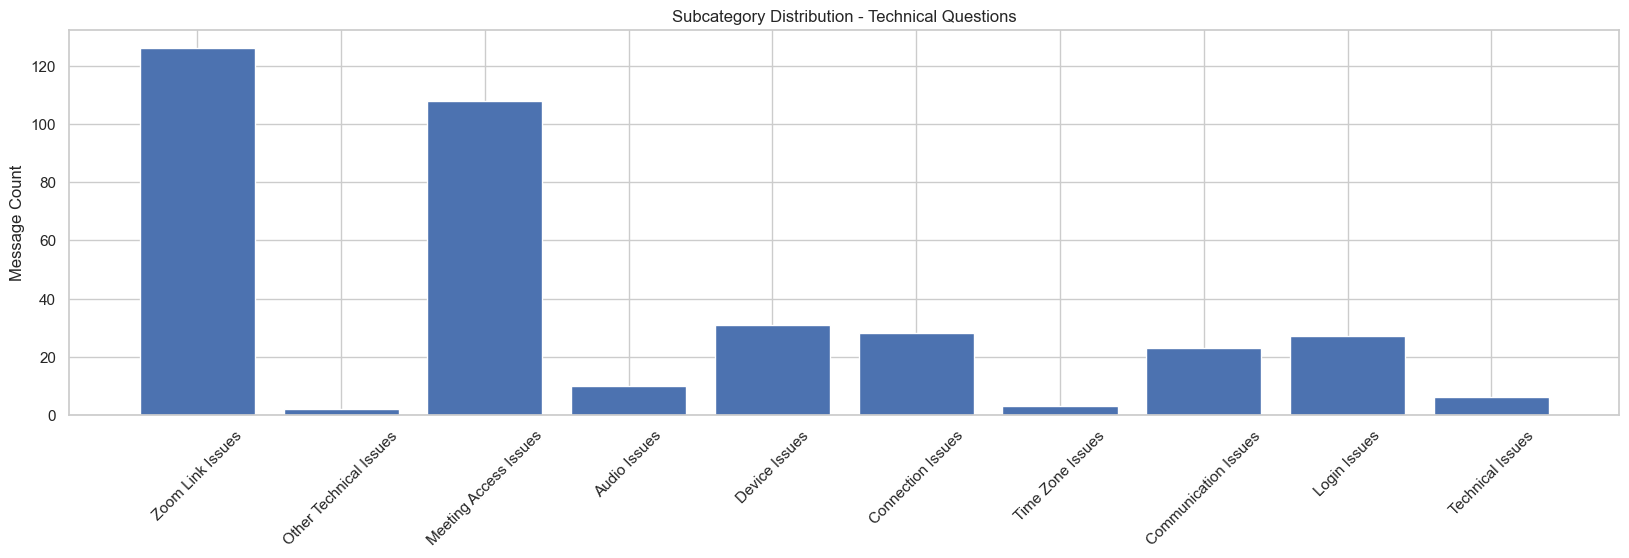

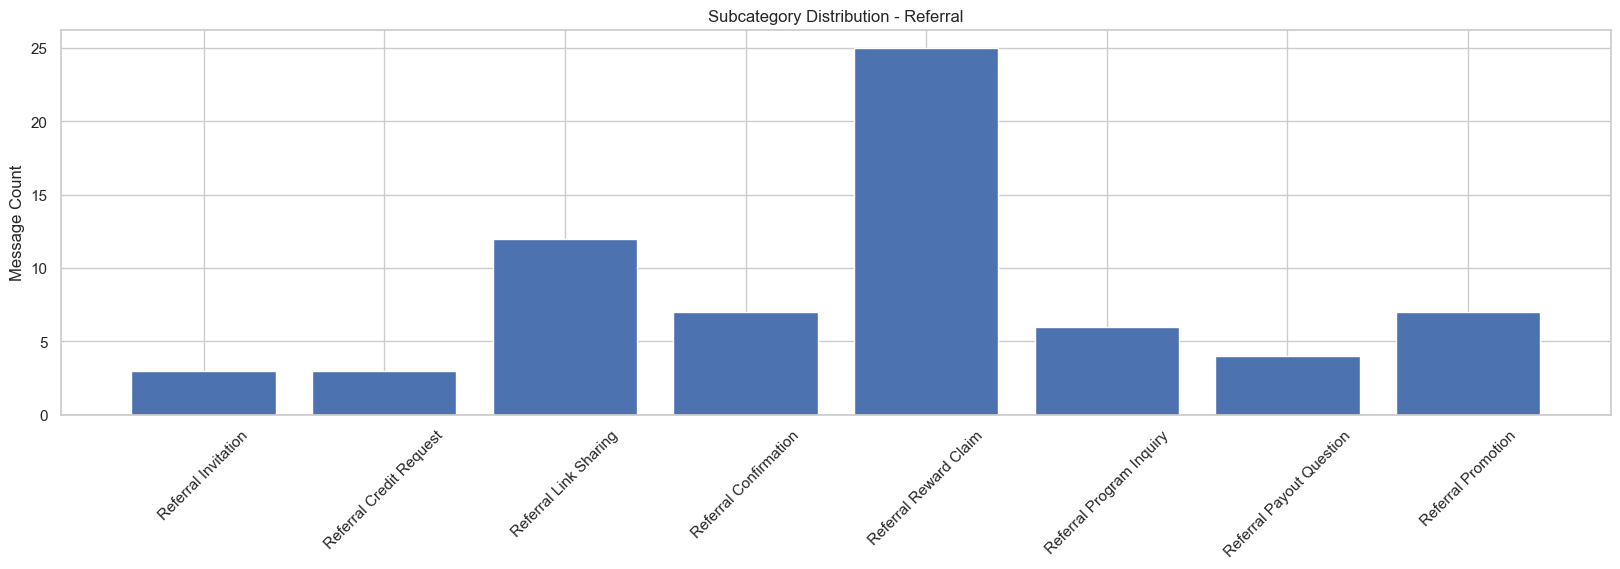

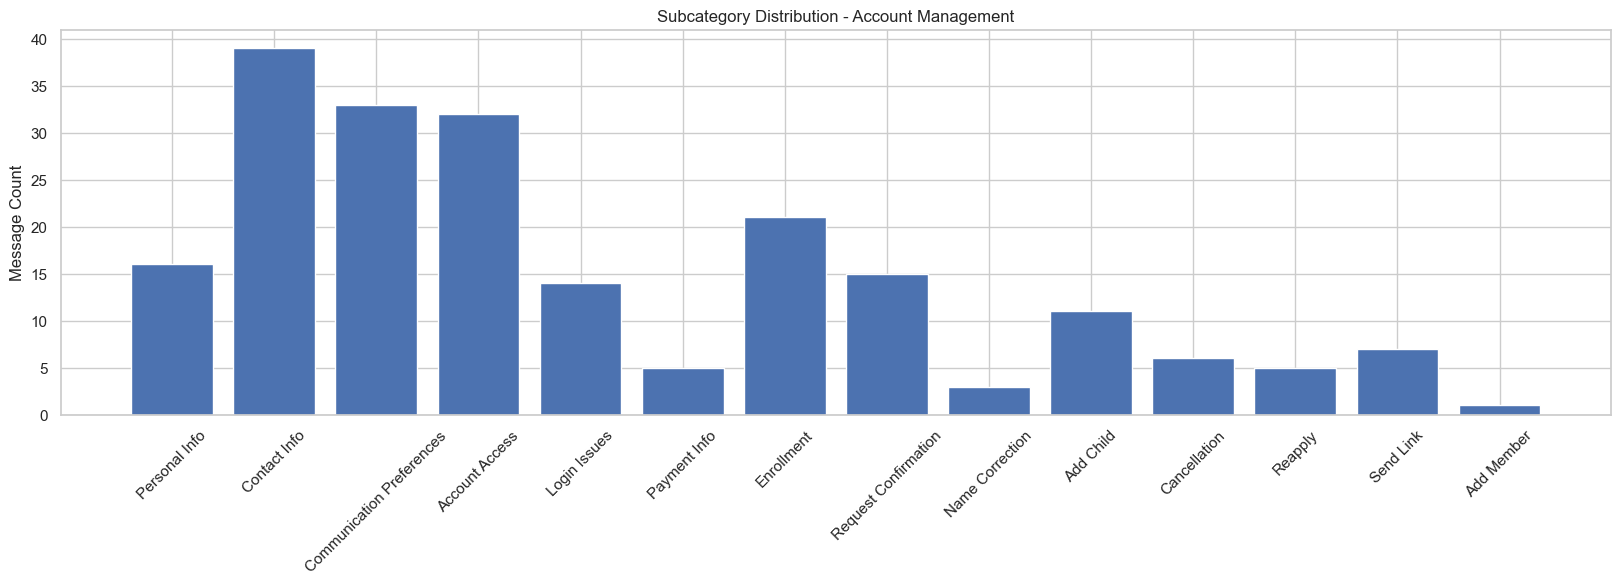

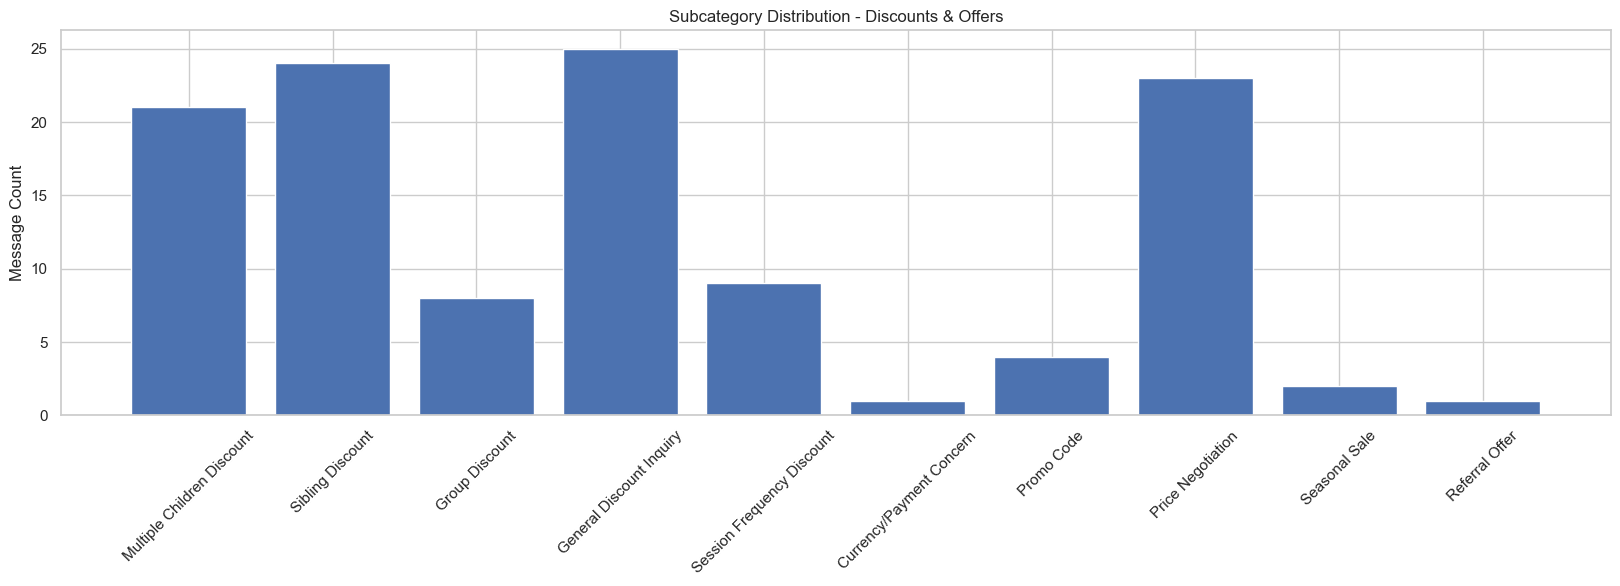

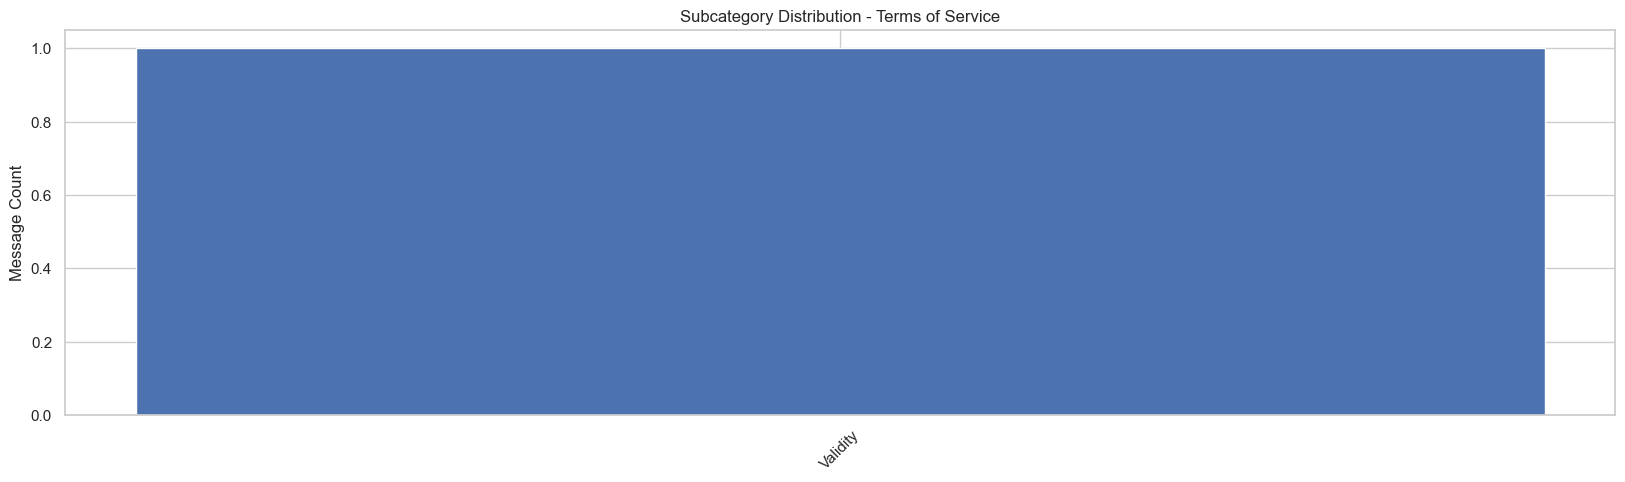

In [22]:
for category in df["category"].unique():
    sub_df = df[df["category"] == category]

    plt.figure(figsize=(20,5))
    plt.bar(sub_df["subcategory"], sub_df["message_count"])
    plt.xticks(rotation=45)
    plt.title(f"Subcategory Distribution - {category}")
    plt.ylabel("Message Count")
    plt.show()


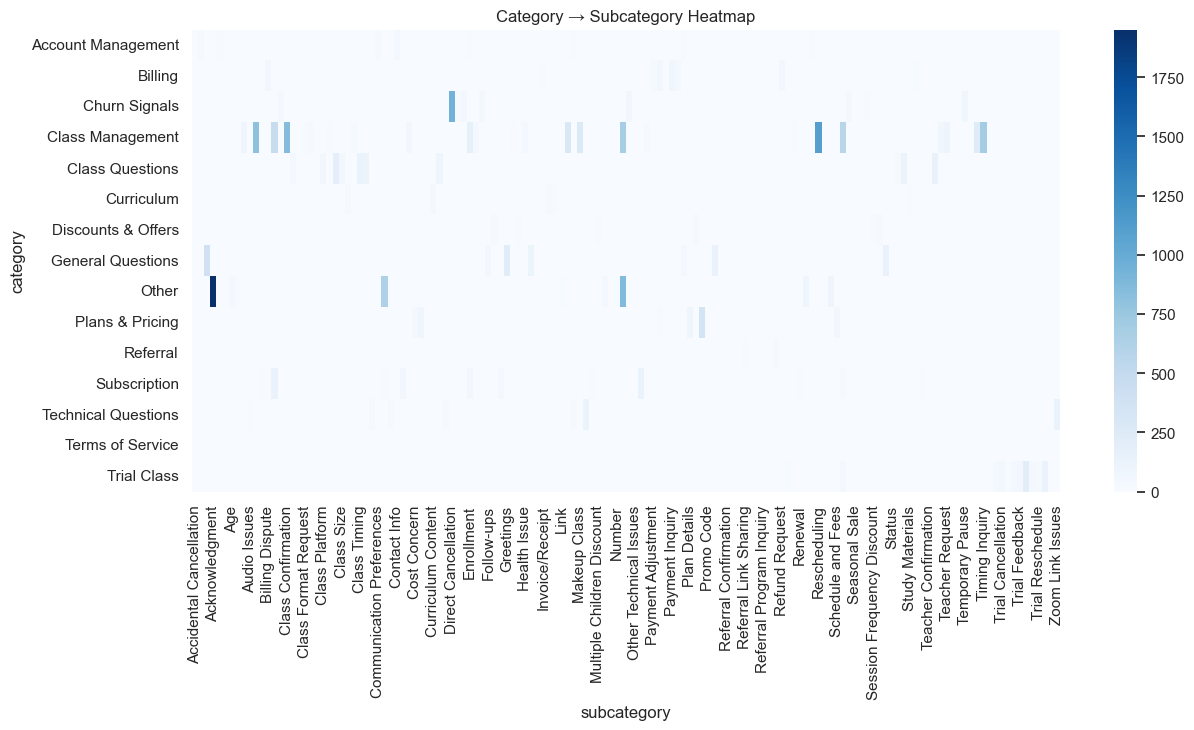

In [10]:
pivot = df.pivot(
    index="category",
    columns="subcategory",
    values="message_count"
).fillna(0)

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap="Blues")
plt.title("Category → Subcategory Heatmap")
plt.show()


In [11]:
pareto = df.sort_values("message_count", ascending=False)
pareto["cumulative"] = pareto["message_count"].cumsum()
pareto["cumulative_percent"] = (
    pareto["cumulative"] / pareto["message_count"].sum() * 100
)

pareto.head(20)


,category,subcategory,message_count,unique_users,category_total,percentage_inside_category,avg_messages_per_user,cumulative,cumulative_percent
12,Other,Acknowledgment,1951,837,3793,51.436857,2.330944,1951,11.373441
30,Class Management,Rescheduling,1109,514,6747,16.436935,2.157588,3060,17.838405
0,Churn Signals,Direct Cancellation,941,286,1341,70.171514,3.290210,4001,23.324006
16,Other,Other,876,478,3793,23.095175,1.832636,4877,28.430687
33,Class Management,Class Confirmation,851,455,6747,12.613013,1.870330,5728,33.391629
36,Class Management,Availability Inquiry,808,372,6747,11.975693,2.172043,6536,38.101900
34,Class Management,Timing Inquiry,695,344,6747,10.300874,2.020349,7231,42.153434
37,Class Management,Other,683,353,6747,10.123018,1.934844,7914,46.135012
18,Other,Confirmation,633,502,3793,16.688637,1.260956,8547,49.825114
40,Class Management,Scheduling,576,283,6747,8.537128,2.035336,9123,53.182931


In [12]:
subcat_counts = df.groupby("category")["subcategory"].count()
subcat_counts


category
Account Management     14
Billing                 8
Churn Signals          12
Class Management       26
Class Questions        12
Curriculum              7
Discounts & Offers     10
General Questions       7
Other                  11
Plans & Pricing         6
Referral                8
Subscription           11
Technical Questions    10
Terms of Service        1
Trial Class            11
Name: subcategory, dtype: int64

In [13]:
concentration = df.groupby("category")["percentage_inside_category"].max()
concentration


category
Account Management      18.750000
Billing                 21.195652
Churn Signals           70.171514
Class Management        16.436935
Class Questions         19.290928
Curriculum              34.965035
Discounts & Offers      21.186441
General Questions       35.529831
Other                   51.436857
Plans & Pricing         55.676516
Referral                37.313433
Subscription            23.783784
Technical Questions     34.615385
Terms of Service       100.000000
Trial Class             29.143646
Name: percentage_inside_category, dtype: float64

In [14]:
low_volume = df[df["percentage_inside_category"] < 5]
low_volume


,category,subcategory,message_count,unique_users,category_total,percentage_inside_category,avg_messages_per_user
1,Churn Signals,Dissatisfaction,63,26,1341,4.697987,2.423077
2,Churn Signals,Scheduling Issues,52,24,1341,3.877703,2.166667
3,Churn Signals,Child Disinterest,45,17,1341,3.355705,2.647059
5,Churn Signals,Financial Reasons,42,12,1341,3.131991,3.500000
7,Churn Signals,Teacher Resignation,5,2,1341,0.372856,2.500000
...,...,...,...,...,...,...,...
142,Account Management,Add Member,1,1,208,0.480769,1.000000
148,Discounts & Offers,Currency/Payment Concern,1,1,118,0.847458,1.000000
149,Discounts & Offers,Promo Code,4,3,118,3.389831,1.333333
151,Discounts & Offers,Seasonal Sale,2,2,118,1.694915,1.000000


In [15]:
registry_versions = {
    category: len(meta["known_subcategories"])
    for category, meta in registry.items()
}

registry_versions


{'Churn Signals': 8,
 'Other': 8,
 'General Questions': 5,
 'Class Management': 9,
 'Class Questions': 5,
 'Trial Class': 8,
 'Curriculum': 7,
 'Plans & Pricing': 5,
 'Subscription': 11,
 'Billing': 6,
 'Technical Questions': 8,
 'Referral': 6,
 'Account Management': 14,
 'Discounts & Offers': 7,
 'Terms of Service': 1}

In [16]:
df["engagement_score"] = (
    df["message_count"] * df["avg_messages_per_user"]
)

df.sort_values("engagement_score", ascending=False).head(10)


,category,subcategory,message_count,unique_users,category_total,percentage_inside_category,avg_messages_per_user,engagement_score
12,Other,Acknowledgment,1951,837,3793,51.436857,2.330944,4547.671446
0,Churn Signals,Direct Cancellation,941,286,1341,70.171514,3.290210,3096.087413
30,Class Management,Rescheduling,1109,514,6747,16.436935,2.157588,2392.764591
36,Class Management,Availability Inquiry,808,372,6747,11.975693,2.172043,1755.010753
16,Other,Other,876,478,3793,23.095175,1.832636,1605.389121
33,Class Management,Class Confirmation,851,455,6747,12.613013,1.870330,1591.650549
34,Class Management,Timing Inquiry,695,344,6747,10.300874,2.020349,1404.142442
37,Class Management,Other,683,353,6747,10.123018,1.934844,1321.498584
40,Class Management,Scheduling,576,283,6747,8.537128,2.035336,1172.353357
24,General Questions,Acknowledgements,399,175,1123,35.529831,2.280000,909.720000


In [17]:
dominance = df.groupby("category")["message_count"].sum()
dominance / dominance.sum() * 100


category
Account Management      1.212545
Billing                 2.145272
Churn Signals           7.817419
Class Management       39.331934
Class Questions         5.590533
Curriculum              0.833625
Discounts & Offers      0.687886
General Questions       6.546578
Other                  22.111461
Plans & Pricing         3.748397
Referral                0.390579
Subscription            3.235397
Technical Questions     2.121954
Terms of Service        0.005830
Trial Class             4.220590
Name: message_count, dtype: float64

In [19]:
df.groupby("category")["message_count"].std()


category
Account Management      12.177262
Billing                 24.307553
Churn Signals          262.561205
Class Management       325.217619
Class Questions         57.386185
Curriculum              15.087049
Discounts & Offers      10.250203
General Questions      120.389447
Other                  607.329699
Plans & Pricing        126.005423
Referral                 7.327785
Subscription            44.259154
Technical Questions     44.023226
Terms of Service              NaN
Trial Class             56.887289
Name: message_count, dtype: float64

In [20]:
df["signal_strength"] = (
    df["percentage_inside_category"] * df["unique_users"]
)

df.sort_values("signal_strength", ascending=False).head(15)


,category,subcategory,message_count,unique_users,category_total,percentage_inside_category,avg_messages_per_user,engagement_score,signal_strength
12,Other,Acknowledgment,1951,837,3793,51.436857,2.330944,4547.671446,43052.649618
0,Churn Signals,Direct Cancellation,941,286,1341,70.171514,3.290210,3096.087413,20069.052946
86,Plans & Pricing,Pricing Inquiry,358,268,643,55.676516,1.335821,478.223881,14921.306376
16,Other,Other,876,478,3793,23.095175,1.832636,1605.389121,11039.493804
30,Class Management,Rescheduling,1109,514,6747,16.436935,2.157588,2392.764591,8448.584556
18,Other,Confirmation,633,502,3793,16.688637,1.260956,798.185259,8377.695755
24,General Questions,Acknowledgements,399,175,1123,35.529831,2.280000,909.720000,6217.720392
33,Class Management,Class Confirmation,851,455,6747,12.613013,1.870330,1591.650549,5738.921002
36,Class Management,Availability Inquiry,808,372,6747,11.975693,2.172043,1755.010753,4454.957759
68,Trial Class,Trial Inquiry,211,141,724,29.143646,1.496454,315.751773,4109.254144
